# Feature Extraction

## Imports

In [1]:
from pathlib import Path, PurePath
import mne
%matplotlib inline
mne.viz.set_browser_backend("matplotlib")
import gpt3_tokenizer
from features import get_raw_tensor, get_feature_tensor
from EEGDataset import EEGDataset
from Session import Session
from DataLoaders import DataLoaders
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Subset
import re
import json

Using matplotlib as 2D backend.


## Load Data

In [2]:
baseline = []
main = []

preprocessed_dir = Path("./../EEG_data/preprocessed/")
# paths for baseline and main folders
baseline_dir = preprocessed_dir / "baseline"
main_dir = preprocessed_dir / "main"

bs_stages = ["eyes closed", "eyes open"]
mn_stages = [
    "reading_1",
    "reading_2",
    "reading_3",
    "reading_4",
    "reading_5",
]
# populate baseline
for session in baseline_dir.iterdir():
    sess = Session(kind="bs")
    st_dict = dict.fromkeys(bs_stages)
    bs_fif = list(session.glob("*.fif"))[0]
    fif = mne.io.read_raw_fif(bs_fif)
    sess.raw = fif
    for stage in session.iterdir():
        if stage != bs_fif:
            for fif_file in stage.iterdir():
                fif = mne.read_epochs(fif_file)
                key = PurePath(stage).name
                st_dict[key] = fif
    sess.stages = st_dict
    baseline.append(sess)
# populate main
for session in main_dir.iterdir():
    sess = Session(kind="mn")
    st_dict = dict.fromkeys(mn_stages)
    mn_fif = list(session.glob("*.fif"))[0]
    fif = mne.io.read_raw_fif(mn_fif)
    sess.raw = fif
    for stage in session.iterdir():
        key = PurePath(stage).name
        if (re.search("red_screen_*", key)):
            print(key)
            continue
        if stage != mn_fif:
            for fif_file in stage.iterdir():
                fif = mne.read_epochs(fif_file)
                st_dict[key] = fif
    sess.stages = st_dict
    main.append(sess)

Opening raw data file ../EEG_data/preprocessed/baseline/2026-04-10_Aminov/2026-04-10_Aminov_raw.fif...
    Range : 0 ... 150167 =      0.000 ...   600.668 secs
Ready.
Reading /Users/fountainer/Downloads/eeg research/eeg-to-code/feature_extraction/../EEG_data/preprocessed/baseline/2026-04-10_Aminov/eyes open/2026-04-10_Aminov_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   14996.00 ms
        0 CTF compensation matrices available
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/fountainer/Downloads/eeg research/eeg-to-code/feature_extraction/../EEG_data/preprocessed/baseline/2026-04-10_Aminov/eyes closed/2026-04-10_Aminov_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   14996.00 ms
        0 CTF compensation matrices available
Not setting metadata
19 matching events found
No baseline correction applied
0 projection items activated
Opening raw data file ../EEG_data/pre

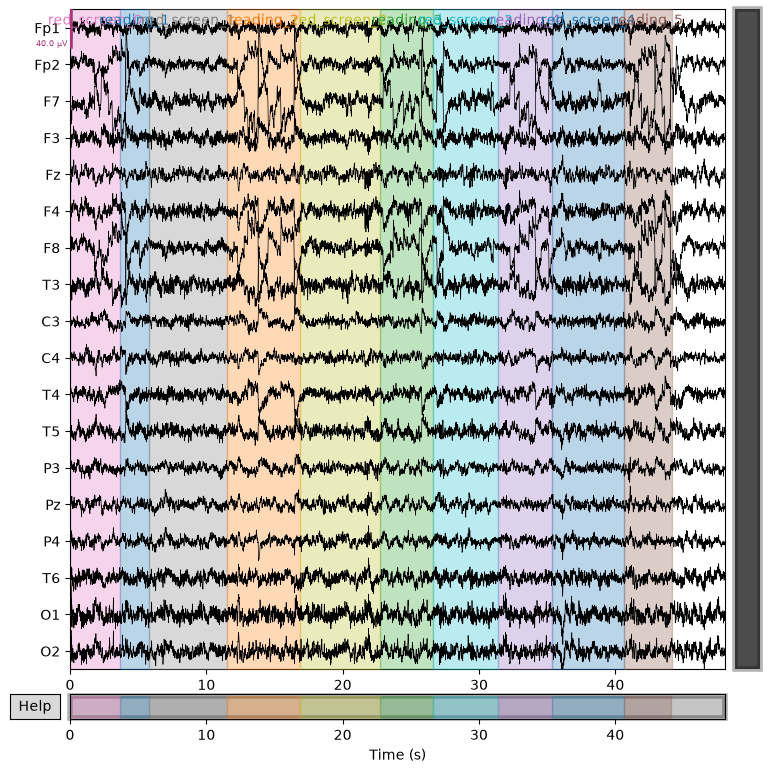

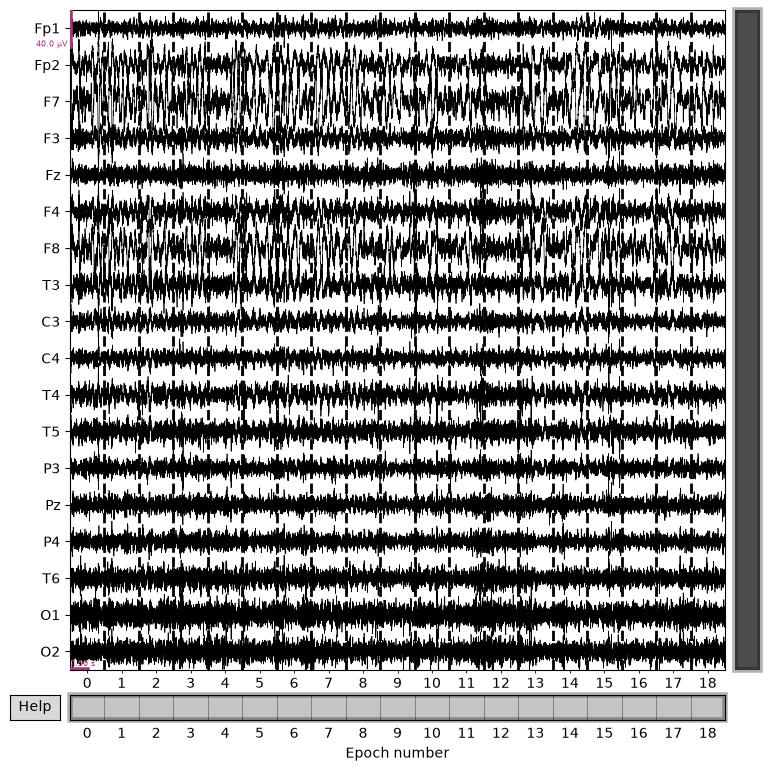

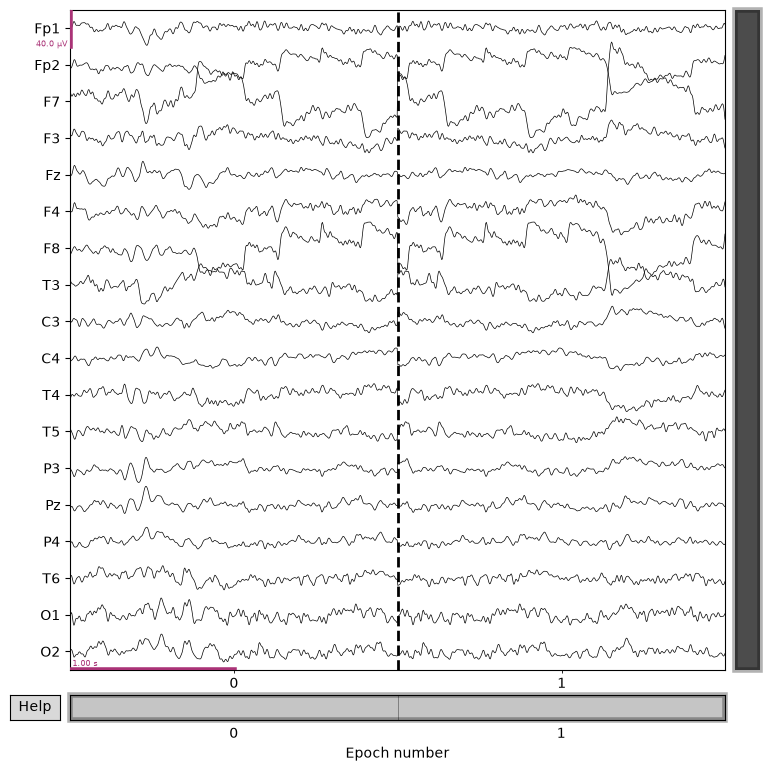

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


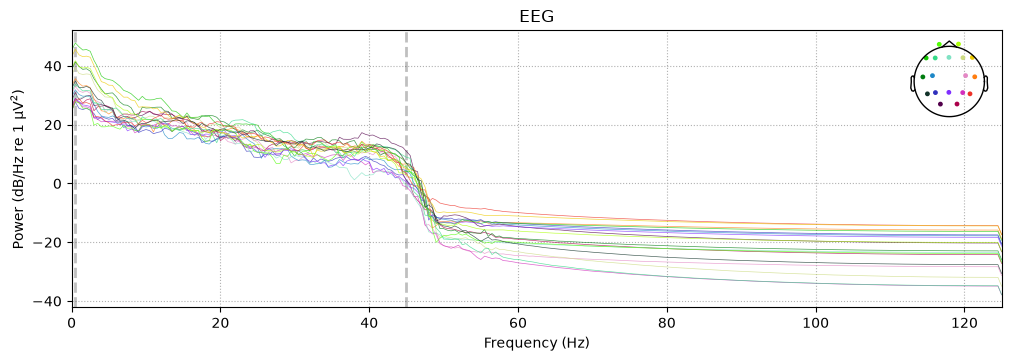

In [3]:
# loaded data examples
main[0].raw.plot(duration=50);
baseline[0].stages["eyes closed"].plot();
main[0].stages["reading_5"].plot();
main[0].stages["reading_1"].compute_psd().plot();

## Get Feature Tensors

In [4]:
get_feature_tensor(main[0].stages["reading_5"], "mn")

tensor([[6.0272e-01, 6.3695e-02, 2.4105e-01, 2.2195e-02, 1.4611e-02, 4.4258e-01,
         7.4072e-02, 3.8616e-01, 5.1206e-02, 1.4042e-02, 7.1092e-01, 6.8367e-02,
         9.1004e-02, 2.2730e-02, 5.6453e-03, 2.9056e-01, 2.4595e-01, 1.9082e-01,
         1.7593e-01, 3.0942e-02, 3.8445e-01, 2.7975e-01, 2.3231e-01, 8.4969e-02,
         5.7242e-03, 4.9451e-01, 1.2508e-01, 2.4506e-01, 9.7779e-02, 1.3756e-02,
         4.5693e-01, 7.5688e-02, 3.5997e-01, 4.6716e-02, 4.7979e-03, 7.7167e-01,
         4.4907e-02, 8.4974e-02, 2.1296e-02, 4.1741e-03, 2.6093e-01, 2.7727e-01,
         2.4237e-01, 1.6459e-01, 1.8673e-02, 6.9246e-01, 4.4603e-02, 1.0732e-01,
         7.3235e-02, 5.3127e-03, 1.8294e-01, 8.7755e-02, 4.7129e-01, 2.1000e-01,
         2.2932e-02, 5.4008e-01, 5.2837e-02, 2.7617e-01, 9.1076e-02, 1.6659e-02,
         2.4942e-01, 1.5552e-01, 4.7966e-01, 1.0055e-01, 3.9255e-03, 5.1215e-01,
         3.1324e-02, 3.5966e-01, 7.4707e-02, 2.2506e-03, 6.5966e-01, 6.5115e-02,
         1.4908e-01, 5.2081e

In [5]:
for session in main:
    session.set_tensors()

for session in baseline:
    session.set_tensors()

# Tokenize Prompts

In [6]:
prompts = [
    "Write a function to compute the area of a rectangle",
    "Write a function to compute the perimeter of a circle by radius",
    "Write a function to convert Celsius to Farenheit",
    "Write a function to check if a number is prime",
    "Write a function to return the factorial of n",
]

tokens = [gpt3_tokenizer.encode(prompt) for prompt in prompts]

max_len = max(len(t) for t in tokens)
pad_token = 0
tokens = [t + [pad_token] * (max_len - len(t)) for t in tokens]

for prompt, token in zip(prompts, tokens):
    print(prompt, ":", token)

annotations = {
    "reading_1": {"prompt": prompts[0], "tokens": tokens[0]},
    "reading_2": {"prompt": prompts[1], "tokens": tokens[1]},
    "reading_3": {"prompt": prompts[2], "tokens": tokens[2]},
    "reading_4": {"prompt": prompts[3], "tokens": tokens[3]},
    "reading_5": {"prompt": prompts[4], "tokens": tokens[4]},
}

Write a function to compute the area of a rectangle : [16594, 257, 2163, 284, 24061, 262, 1989, 286, 257, 35991, 0, 0]
Write a function to compute the perimeter of a circle by radius : [16594, 257, 2163, 284, 24061, 262, 25317, 286, 257, 9197, 416, 16874]
Write a function to convert Celsius to Farenheit : [16594, 257, 2163, 284, 10385, 34186, 284, 376, 5757, 29361, 0, 0]
Write a function to check if a number is prime : [16594, 257, 2163, 284, 2198, 611, 257, 1271, 318, 6994, 0, 0]
Write a function to return the factorial of n : [16594, 257, 2163, 284, 1441, 262, 1109, 5132, 286, 299, 0, 0]


## Create a Custom EEG Dataset

In [7]:
# structure of input & output

# for one session main[0]
# for each stage & each epoch ([0] is an epoch)
main[0].get_tensors()["reading_1"]["raw"][0]  # first input tensor
main[0].get_tensors()["reading_1"]["processed"][0]  # second input tensor
# for the whole session I will additionally feed session baselines so the model uses it
baseline[0].get_tensors()["eyes closed"]["processed"]  # baseline input tensor
annotations["reading_1"]["tokens"]  # output label

# so the input is
# tuple(main[0].get_tensors()["reading_1"]["raw"][0],
#   main[0].get_tensors()["reading_1"]["processed"][0], baseline[0].get_tensors()["eyes open"]["processed"],
#    self.baseline[session_idx].get_tensors()["eyes closed"]["processed"])
# and the associated label is annotations["reading_1"]["tokens"]

[16594, 257, 2163, 284, 24061, 262, 1989, 286, 257, 35991, 0, 0]

In [8]:
# build an index for a dataset so each epoch is binded to a number
epochs = []
for session_ind, session in enumerate(main):
    for stage in session.get_stages():
        for epoch_ind, epoch in enumerate(session.get_stages()[stage]):
            epochs.append((session_ind, stage, epoch_ind))
index_from_triple = dict.fromkeys(epochs)
index_from_idx = dict.fromkeys([x for x, y in enumerate(epochs)])
for ind, key in enumerate(index_from_triple):
    index_from_triple[key] = ind
    index_from_idx[ind] = key
print(index_from_triple)
print(index_from_idx)

{(0, 'reading_1', 0): 0, (0, 'reading_2', 0): 1, (0, 'reading_2', 1): 2, (0, 'reading_2', 2): 3, (0, 'reading_2', 3): 4, (0, 'reading_3', 0): 5, (0, 'reading_3', 1): 6, (0, 'reading_4', 0): 7, (0, 'reading_4', 1): 8, (0, 'reading_4', 2): 9, (0, 'reading_5', 0): 10, (0, 'reading_5', 1): 11, (1, 'reading_1', 0): 12, (1, 'reading_1', 1): 13, (1, 'reading_1', 2): 14, (1, 'reading_1', 3): 15, (1, 'reading_2', 0): 16, (1, 'reading_3', 0): 17, (1, 'reading_3', 1): 18, (1, 'reading_4', 0): 19, (1, 'reading_5', 0): 20, (2, 'reading_1', 0): 21, (2, 'reading_1', 1): 22, (2, 'reading_1', 2): 23, (2, 'reading_1', 3): 24, (2, 'reading_1', 4): 25, (2, 'reading_2', 0): 26, (2, 'reading_2', 1): 27, (2, 'reading_3', 0): 28, (2, 'reading_4', 0): 29, (2, 'reading_4', 1): 30, (2, 'reading_5', 0): 31, (3, 'reading_1', 0): 32, (3, 'reading_1', 1): 33, (3, 'reading_1', 2): 34, (3, 'reading_1', 3): 35, (3, 'reading_1', 4): 36, (3, 'reading_1', 5): 37, (3, 'reading_1', 6): 38, (3, 'reading_1', 7): 39, (3, 'read

In [9]:
# create a Dataset instance
dataset = EEGDataset(
    annotations=annotations,
    main_sessions=main,
    baseline_sessions=baseline,
    index_from_triple=index_from_triple,
    index_from_idx=index_from_idx,
)

In [10]:
features_dir = Path("./../EEG_data/")
datasets_dir = features_dir / "datasets"
datasets_dir.mkdir(parents=True, exist_ok=True)

torch.save(dataset, datasets_dir / "dataset.pt")

## Data Splits

In [11]:
# subject-wise splits
subj_splits_list = []
for sess_ind,session in enumerate(main):
    sess_splits = []
    for stage in session.get_stages():
        for ep_ind,epoch in enumerate(session.get_stages()[stage]):
            ind = index_from_triple[(sess_ind, stage, ep_ind)]
            sess_splits = sess_splits + [ind]
    subj_splits_list.append(sess_splits)
print(subj_splits_list)
print(len(subj_splits_list))
# prompt_wise splits
prompt_splits_list = []
for stage in annotations.keys():
    st_splits = []
    for sess_ind,session in enumerate(main):
        for ep_ind,epoch in enumerate(session.get_tensors()[stage]["raw"]):
            ind = index_from_triple[(sess_ind, stage, ep_ind)]
            st_splits.append(ind)
    prompt_splits_list.append(st_splits)
print(prompt_splits_list)
print(len(prompt_splits_list))

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [12, 13, 14, 15, 16, 17, 18, 19, 20], [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31], [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67], [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84], [85, 86, 87, 88, 89, 90, 91, 92, 93, 94], [95, 96, 97, 98, 99, 100]]
7
[[0, 12, 13, 14, 15, 21, 22, 23, 24, 25, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 68, 69, 70, 71, 85, 86, 87, 95, 96], [1, 2, 3, 4, 16, 26, 27, 45, 46, 47, 48, 49, 50, 72, 73, 74, 88, 89, 97], [5, 6, 17, 18, 28, 51, 52, 53, 54, 55, 56, 57, 75, 76, 77, 78, 90, 91, 98], [7, 8, 9, 19, 29, 30, 58, 59, 60, 61, 62, 79, 80, 81, 82, 92, 99], [10, 11, 20, 31, 63, 64, 65, 66, 67, 83, 84, 93, 94, 100]]
5


## Dataset Splits: Subject-Wise, Prompt-Wise

In [12]:
# subject-wise (7): 5 sessions for training, 1 for testing, 1 for validation
# prompt-wise (5): 3 prompts for training, 1 for testing, 1 for validation
subj_splits = []
subj_train = []
for session in subj_splits_list[:5]:
    indices = [ index for index in session ]
    subj_train.extend(indices)
subj_test = subj_splits_list[5]
subj_validate = subj_splits_list[6]
subj_splits = {
    "train": subj_train,
    "test": subj_test,
    "validate": subj_validate,
}

prompt_splits = []
prompt_train = []
for session in prompt_splits_list[:3]:
    indices = [ index for index in session ]
    prompt_train.extend(indices)
prompt_test = prompt_splits_list[3]
prompt_validate = prompt_splits_list[4]
prompt_splits = {
    "train": prompt_train,
    "test": prompt_test,
    "validate": prompt_validate,
}

In [13]:
# save frozen splits into files

data_dir = Path("./../EEG_data/")
splits_dir = data_dir / "splits"
splits_dir.mkdir(parents=True, exist_ok=True)

subj_splits_dir = splits_dir / "subj_splits.json"
with open(subj_splits_dir, "w") as file:
    json.dump(subj_splits, file, indent=2)

prompt_splits_dir = splits_dir / "prompt_splits.json"
with open(prompt_splits_dir, "w") as file:
    json.dump(prompt_splits, file, indent=2)

## DataLoaders

In [15]:
subj_path = "./../EEG_data/splits/subj_splits.json"
prompt_path = "./../EEG_data/splits/prompt_splits.json"

subj = []
with open(subj_path, "r") as file:
    subj = json.load(file)

prompt = []
with open(prompt_path, "r") as file:
    prompt = json.load(file)

torch.save(subj, datasets_dir / "subj_dataset.pt")
torch.save(prompt, datasets_dir / "prompt_dataset.pt")

In [16]:
dataLoaders = DataLoaders(dataset_path=datasets_dir / "dataset.pt", subj_path=datasets_dir / "subj_dataset.pt", prompt_path=datasets_dir / "prompt_dataset.pt")

In [17]:
# examples
train_features, train_labels = dataLoaders.next("s", "train")

print("_______LABELS_______")
for stage, token in zip(train_labels["stage"], train_labels["tokens"]):
    print("STAGE")
    print(stage)
    print("TOKENS")
    print(token)
    break

print("_______DATA_______")
for raw, feature, eyes_open, eyes_closed in zip(
    train_features["raw"],
    train_features["feature"],
    train_features["eyes_open"],
    train_features["eyes_closed"],
):
    print("RAW")
    print(raw)
    print("FEATURE")
    print(feature)
    print("OPEN")
    print(eyes_open)
    print("CLOSED")
    print(eyes_closed)
    break

_______LABELS_______
STAGE
reading_1
TOKENS
tensor([16594.,   257.,  2163.,   284., 24061.,   262.,  1989.,   286.,   257.,
        35991.,     0.,     0.])
_______DATA_______
RAW
tensor([[ 2.9305e-06,  4.2860e-06,  4.8876e-06,  ...,  1.1286e-06,
          1.4222e-06,  1.7584e-06],
        [ 4.3454e-06,  4.6910e-06,  4.7549e-06,  ...,  8.6330e-06,
          8.3287e-06,  8.1978e-06],
        [-3.5339e-07,  3.9752e-06,  6.1108e-06,  ..., -1.1317e-05,
         -9.4309e-06, -7.6464e-06],
        ...,
        [-3.2829e-06, -3.4407e-06, -3.6099e-06,  ..., -1.6515e-06,
         -7.9229e-07,  6.6462e-09],
        [ 2.9842e-06,  1.2717e-06,  1.0529e-06,  ..., -2.4856e-06,
         -2.9079e-06, -3.7928e-06],
        [ 3.8622e-07, -3.1218e-06, -5.6149e-06,  ..., -4.6051e-06,
         -4.0534e-06, -4.1204e-06]], dtype=torch.float64)
FEATURE
tensor([4.1093e-01, 1.5593e-01, 5.0298e-02, 2.8298e-01, 9.4314e-02, 3.9561e-01,
        4.5805e-02, 1.8976e-01, 3.3129e-01, 3.2396e-02, 4.3294e-01, 1.0913e-01,